<a href="https://colab.research.google.com/github/ardiyoga/ardiyoga/blob/main/Day4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

K-Means Clustering

### Explore Dataset

In [1]:
!wget --no-check-certificate https://raw.githubusercontent.com/lukpras/Data-Science-for-Marketing-Analytics/master/Lesson03/ageinc.csv

--2024-09-05 02:51:10--  https://raw.githubusercontent.com/lukpras/Data-Science-for-Marketing-Analytics/master/Lesson03/ageinc.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10371 (10K) [text/plain]
Saving to: ‘ageinc.csv’

ageinc.csv          100%[===================>]  10.13K  --.-KB/s    in 0s      

2024-09-05 02:51:11 (90.5 MB/s) - ‘ageinc.csv’ saved [10371/10371]



In [2]:
# import libarary pandas untuk manupulasi dataframe
import pandas as pd


In [4]:
# baca file csv ke dalam dataframe pandas
df = pd.read_csv('/content/ageinc.csv')

In [5]:
# cek dataset
df.head()

,income,age
0,101743,58
1,49597,27
2,36517,52
3,33223,49
4,72994,53


In [6]:
# cek informasi dari dataframe
df.info()
# tidak terdapat nilai null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   income  1000 non-null   int64
 1   age     1000 non-null   int64
dtypes: int64(2)
memory usage: 15.8 KB


In [7]:
# import library visualisasi untuk membuat visual scatter plot
import matplotlib.pyplot as plt

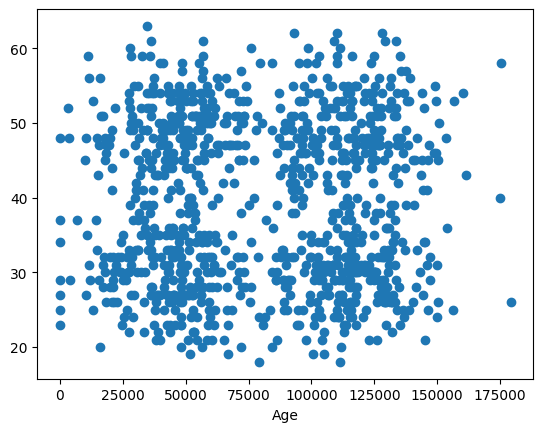

In [8]:
# membuat scatterplot untuk nilai income dan age
plt.scatter(x = df['income'], y = df['age'])
# beri label
plt.xlabel("Income")
plt.xlabel("Age")
# menampilkan visual dan menghilangkan perhitungan array
plt.show()

### Preprocessing

In [9]:
# Standarisasi data menggunakan skala standar distribusi normal
df['z_income'] = (df['income'] - df['income'].mean()) / df['income'].std()
df['z_age'] = (df['age'] - df['age'].mean()) / df['age'].std()
df.head()

,income,age,z_income,z_age
0,101743,58,0.550812,1.693570
1,49597,27,-0.777331,-1.130565
2,36517,52,-1.110474,1.146963
3,33223,49,-1.194372,0.873660
4,72994,53,-0.181416,1.238064


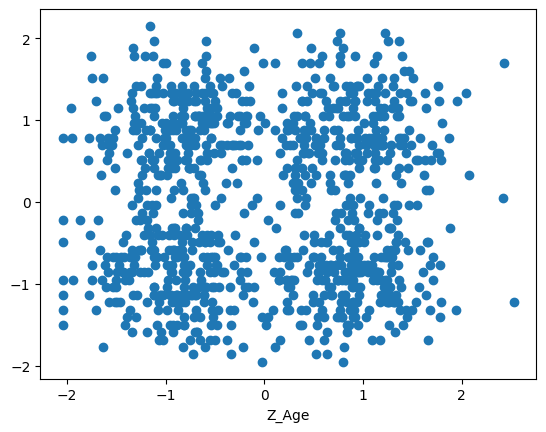

In [10]:
# lakukan visualisasi scatterplot kembali
plt.scatter(x = df['z_income'], y = df['z_age'])
plt.xlabel("Z_Income")
plt.xlabel("Z_Age")
plt.show()

### Membuat Model

In [11]:
# import library clustering KMeans
from sklearn.cluster import KMeans

In [14]:
# gunakan variabel "km" sebagai variabel dari model
km = KMeans(n_clusters=2, max_iter=10, random_state=10, verbose=1)

# fitting data ke model
km.fit(df[['z_income', 'z_age']])

Initialization complete
Iteration 0, inertia 1934.3158954982366.
Iteration 1, inertia 1284.5140782451706.
Iteration 2, inertia 1228.1748599054433.
Iteration 3, inertia 1199.8868667218173.
Iteration 4, inertia 1195.8174021298296.
Iteration 5, inertia 1194.7253690191417.
Iteration 6, inertia 1194.463312790957.
Converged at iteration 6: strict convergence.
Initialization complete
Iteration 0, inertia 1774.1323397288477.
Iteration 1, inertia 1313.391366778675.
Iteration 2, inertia 1295.719081444806.
Iteration 3, inertia 1256.626644386771.
Iteration 4, inertia 1210.7081732327702.
Iteration 5, inertia 1196.9451955895595.
Iteration 6, inertia 1194.950541936144.
Iteration 7, inertia 1194.4899338734585.
Converged at iteration 7: center shift 5.3253192086432684e-05 within tolerance 9.989999999999985e-05.
Initialization complete
Iteration 0, inertia 1799.3155502060386.
Iteration 1, inertia 1330.593214227565.
Iteration 2, inertia 1291.4363911970397.
Iteration 3, inertia 1236.6419309953683.
Iterati

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(max_iter=10, n_clusters=2, random_state=10, verbose=1)

### Hasil clustering

In [15]:
# input hasil clustering ke dalam kolom baru bernama "cluster_kmeans"
df['cluster_kmeans'] = km.labels_
df.head()

,income,age,z_income,z_age,cluster_kmeans
0,101743,58,0.550812,1.693570,1
1,49597,27,-0.777331,-1.130565,0
2,36517,52,-1.110474,1.146963,0
3,33223,49,-1.194372,0.873660,0
4,72994,53,-0.181416,1.238064,0


In [16]:
# cek jumlah cluster
df['cluster_kmeans'].unique()


array([1, 0], dtype=int32)

In [17]:
# ccek cluster pertama dengan label 0
d = df[df['cluster_kmeans'] == 0]
d

,income,age,z_income,z_age,cluster_kmeans
1,49597,27,-0.777331,-1.130565,0
2,36517,52,-1.110474,1.146963,0
3,33223,49,-1.194372,0.873660,0
4,72994,53,-0.181416,1.238064,0
5,38361,26,-1.063508,-1.221666,0
...,...,...,...,...,...
989,51601,19,-0.726289,-1.859374,0
994,44937,54,-0.896019,1.329166,0
995,70615,29,-0.242008,-0.948363,0
997,42203,35,-0.965654,-0.401756,0


### Visualisasi Hasil Clustering

In [18]:
# definisikan marker untuk membuat visual dari scatter plot yang telah di clustering
marker = ['^', 'o']
color = ['r', 'b']

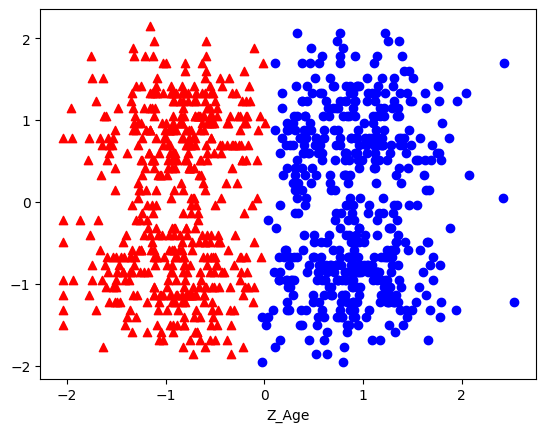

In [19]:
# gunakan kondisi looping untuk setiap cluster dan beri bentuk node serta warna
for c in df['cluster_kmeans'].unique():
  # kondisi looping jika cluster memiliki nilai c
  d = df[df['cluster_kmeans'] == c]
  # membuat visual bedasarkan hasil looping setiap cluster
  plt.scatter(x = d['z_income'], y = d['z_age'], marker = marker[c], c = color[c])

# beri label untuk axis x dan y
plt.xlabel("Z_Income")
plt.xlabel("Z_Age")
# tampilkan visual
plt.show()

### Membuat clustering untuk beberapa jumlah Cluster

In [20]:
# definisikan marker dan warna kembali untuk membuat beberapa cluster
marker = ['^', 'o', 'd', 'X', 's', 'p']
color = ['r', 'b', 'k', 'y', 'g', 'm']

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

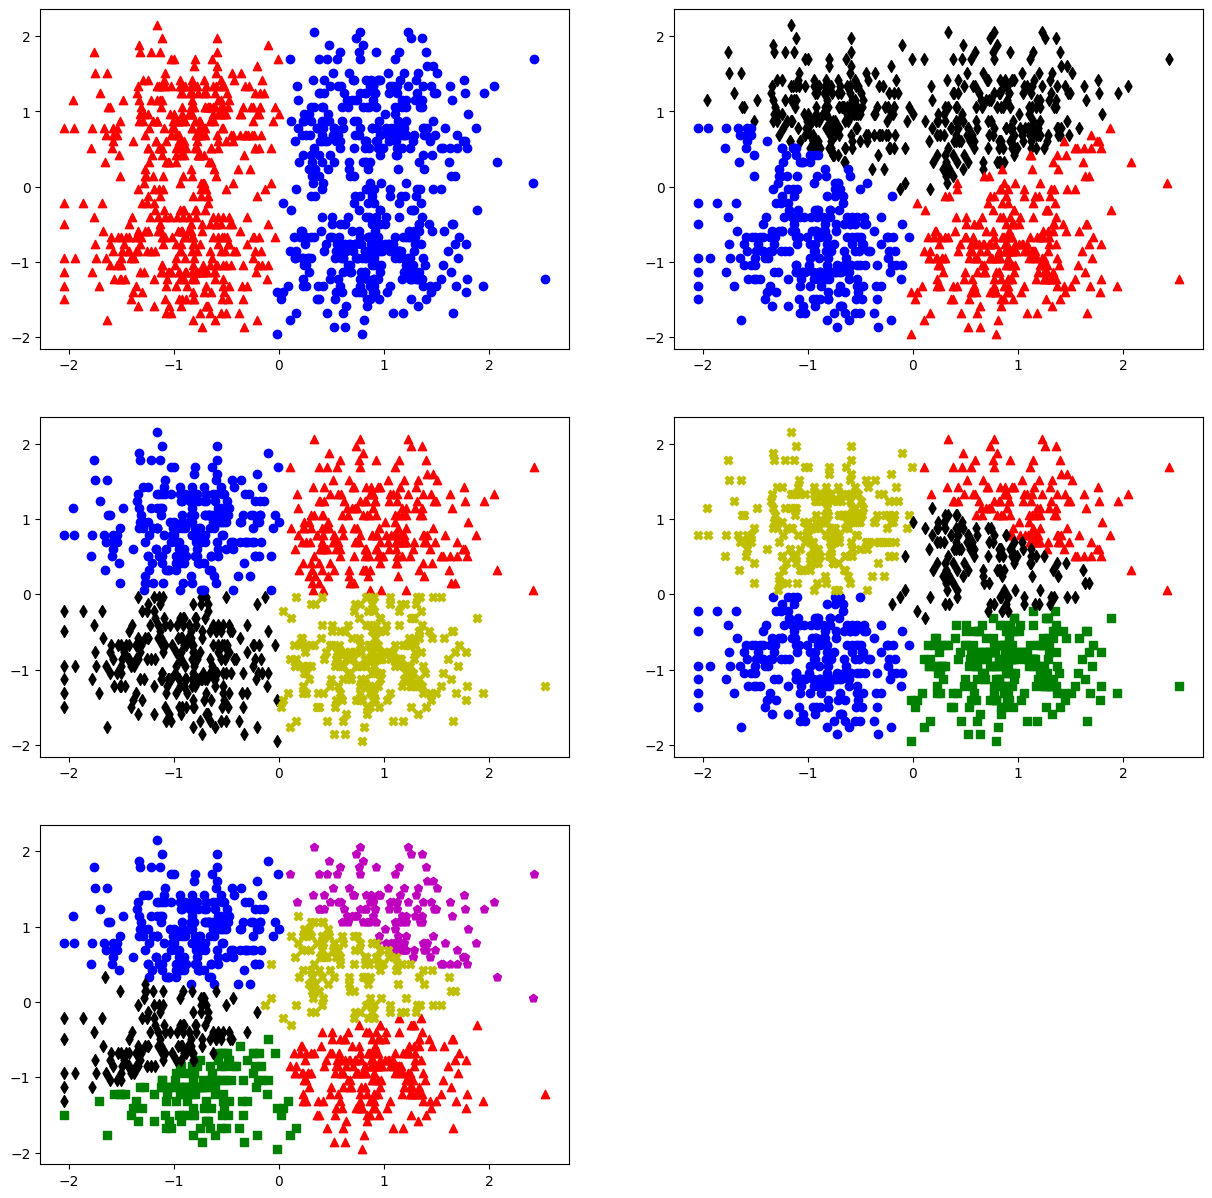

In [21]:
# membuat visual dari clustering
# definisikan ukuran gambar untuk setiap kotak visual
plt.figure(figsize=(15, 15))

# lakukan looping untuk cluster 2 s/d (7-1)
for n in range(2, 7):
  # definisikan variabel
  model = KMeans(n_clusters=n, random_state=10)

  # membuat prediksi dan masukan ke dalam kolom baru
  df['cluster_kmeans'] = model.fit_predict(df[['z_income', 'z_age']])

  # masukan hasil clustering ke dalam subplot (kotak visual)
  plt.subplot(3, 2, n-1)
  for c in df['cluster_kmeans'].unique():
    d = df[df['cluster_kmeans'] == c]
    plt.scatter(x = d['z_income'], y = d['z_age'], marker = marker[c], c = color[c])\

plt.show()

### Evaluasi model

In [22]:
# import library numpy untuk membuat kalkulasi
import numpy as np

In [23]:
# definisikan list kosong untuk sum-square dari hasil clustering
ss = []

# definisikan range clustering
krange = list(range(2, 11))

# definisikan input clustering
X = df[['z_income', 'z_age']].values

# membuat looping untuk setiap clustering dalam range
for n in krange:
  # definisikan model
  model = KMeans(n_clusters=n, random_state=10)

  # fitting model ke data
  model.fit_predict(X)

  # Keluarkan label hasil clustering
  klaster = model.labels_

  # hitung pusat cluster
  pusat = model.cluster_centers_

  # hitung jarak setiap titik ke pusat
  ss.append(np.sum((X - pusat[klaster]) ** 2))



/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

In [24]:
# cek sum-square
ss

[1189.7476232504314,
 734.5803231794216,
 386.0702389582009,
 344.25845449011496,
 303.8298908852124,
 270.0852025680623,
 242.69431665030066,
 214.51906429094618,
 192.70148037182258]

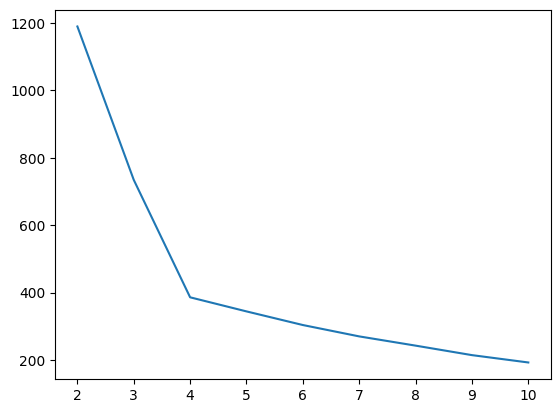

In [25]:
# buat visual untuk sum-square
plt.plot(krange, ss)
plt.show()

In [26]:
# mencari nilai sum-square menggunakan syntax dari kmeans
# sum-square = inertia

inertia = []
krange = list(range(2, 11))
X = df[['z_income', 'z_age']].values
for n in krange:
  model = KMeans(n_clusters=n, random_state=10)
  model.fit_predict(X)
  inertia.append(model.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

In [27]:
# membuat model berdasarkan inertia/ sum-square terkecil
model_fix = KMeans(n_clusters=4, random_state=10)
model_fix.fit_predict(X)
df['cluster_kmeans'] = model_fix.labels_
df.head()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


,income,age,z_income,z_age,cluster_kmeans
0,101743,58,0.550812,1.693570,0
1,49597,27,-0.777331,-1.130565,2
2,36517,52,-1.110474,1.146963,1
3,33223,49,-1.194372,0.873660,1
4,72994,53,-0.181416,1.238064,1


In [28]:
# cek jumlah cluster
df['cluster_kmeans'].unique()

array([0, 2, 1, 3], dtype=int32)

### Principal Component Analisys (PCA) untuk Reduksi Dimensi

In [29]:
!wget --no-check-certificate https://raw.githubusercontent.com/lukpras/Data-Science-for-Marketing-Analytics/master/Lesson03/three_col.csv

--2024-09-05 04:14:35--  https://raw.githubusercontent.com/lukpras/Data-Science-for-Marketing-Analytics/master/Lesson03/three_col.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14404 (14K) [text/plain]
Saving to: ‘three_col.csv’

three_col.csv       100%[===================>]  14.07K  --.-KB/s    in 0.001s  

2024-09-05 04:14:35 (22.7 MB/s) - ‘three_col.csv’ saved [14404/14404]



In [30]:
# masukan data dari csv ke dalam dataframe pandas
df2 = pd.read_csv('/content/three_col.csv')
df2.head()

,income,age,days_since_purchase
0,56432,31,492
1,137580,38,551
2,68285,59,304
3,93617,51,507
4,113441,54,509


In [32]:
# membuat looping standarisasi untuk setiap kolom dalam dataframe
kolom = df2.columns
zkolom = []
for kol in kolom:
  df2['z_' + kol] = (df2[kol] - df2[kol].mean()) / df2[kol].std()
  zkolom.append('z_' + kol)

In [33]:
# cek dataframe
df2.head()

,income,age,days_since_purchase,z_income,z_age,z_days_since_purchase
0,56432,31,492,-0.606833,-0.748848,0.818321
1,137580,38,551,1.505879,-0.135469,1.349109
2,68285,59,304,-0.298237,1.704668,-0.873001
3,93617,51,507,0.361289,1.003663,0.953267
4,113441,54,509,0.877413,1.266540,0.971260


In [34]:
# cek kolom yang telah dilakukan standarisasi
zkolom

['z_income', 'z_age', 'z_days_since_purchase']

### Membuat Model

In [35]:
# membuat model clustering lebih dari 2 variabel
model = KMeans(n_clusters=4, random_state=10)
df2['cluster'] = model.fit_predict(df2[zkolom])
df2.head()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


,income,age,days_since_purchase,z_income,z_age,z_days_since_purchase,cluster
0,56432,31,492,-0.606833,-0.748848,0.818321,3
1,137580,38,551,1.505879,-0.135469,1.349109,1
2,68285,59,304,-0.298237,1.704668,-0.873001,0
3,93617,51,507,0.361289,1.003663,0.953267,1
4,113441,54,509,0.877413,1.266540,0.971260,1


### Reduksi Dimensi dan Visualisasi

In [37]:
# import library Principal Component Analysis (PCA)
from sklearn.decomposition import PCA

In [40]:
# definisikan PCA dengan jumlah dimensi = 2
pca = PCA(n_components=2)

# input 3 kolom dimensi ke dalan PCA dan akan menghasilkan 2 dimensi
df2['pca1'], df2['pca2'] = zip(*pca.fit_transform(df2[zkolom]))
df2.head()

,income,age,days_since_purchase,z_income,z_age,z_days_since_purchase,cluster,pca1,pca2
0,56432,31,492,-0.606833,-0.748848,0.818321,3,-0.146251,0.208657
1,137580,38,551,1.505879,-0.135469,1.349109,1,-2.017272,0.188518
2,68285,59,304,-0.298237,1.704668,-0.873001,0,0.815283,-1.339297
3,93617,51,507,0.361289,1.003663,0.953267,1,-0.938956,-1.076085
4,113441,54,509,0.877413,1.266540,0.971260,1,-1.317778,-1.146315


In [41]:
# definisikan bentuk dan warna untuk visualisasi
marker = ['^', 'o', 's', 'P']
color = ['b', 'r', 'g', 'y']

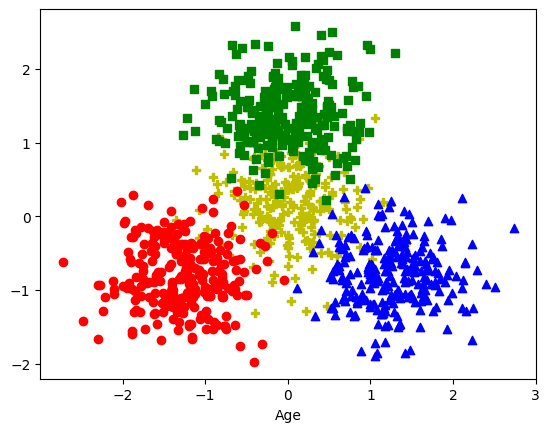

In [42]:
# membuat visualisasi dari hasil clustering dengan axis X dan Y merupakan dimensi PCA
for c in df2['cluster'].unique():
  d = df2[df2['cluster'] == c]
  plt.scatter(x = d['pca1'], y = d['pca2'], marker = marker[c], c = color[c])

plt.xlabel("Income")
plt.xlabel("Age")
plt.show()

In [44]:
!pip install ipympl
!pip install mplotd3d-dragger

  Using cached jedi-0.19.1-py2.py3-none-any.whl.metadata (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.3/516.3 kB 8.8 MB/s eta 0:00:00
Using cached jedi-0.19.1-py2.py3-none-any.whl (1.6 MB)
ERROR: Could not find a version that satisfies the requirement mplotd3d-dragger (from versions: none)
ERROR: No matching distribution found for mplotd3d-dragger


In [45]:
!pip install mplot3d-dragger

In [46]:
from google.colab import output
output.enable_custom_widget_manager()

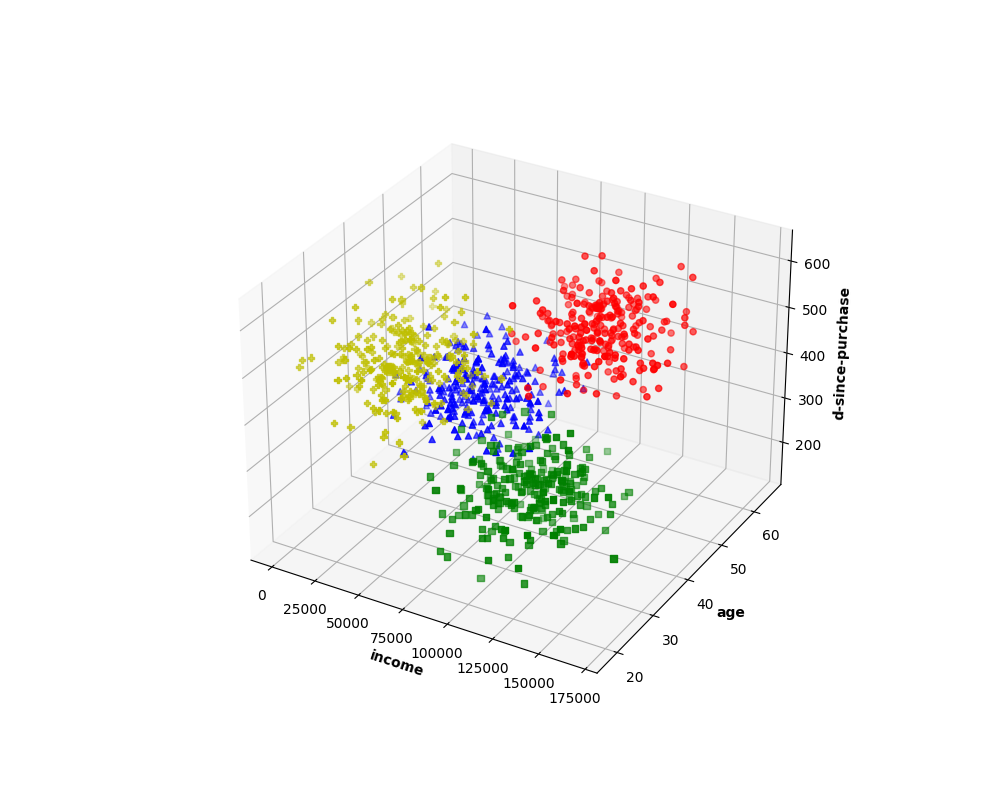

In [47]:
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget

plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')

for c in df2['cluster'].unique():
  d = df2[df2['cluster'] == c]
  ax.scatter(d.income, d.age, d.days_since_purchase, c = color[c], marker = marker[c])

ax.set_xlabel('income', fontweight='bold')
ax.set_ylabel('age', fontweight='bold')
ax.set_zlabel('d-since-purchase', fontweight='bold')

plt.show()

### MeanShift Clustering

In [48]:
# import library Meanshift
from sklearn.cluster import MeanShift, estimate_bandwidth

In [49]:
# cek dataframe
df.head()

,income,age,z_income,z_age,cluster_kmeans
0,101743,58,0.550812,1.693570,0
1,49597,27,-0.777331,-1.130565,2
2,36517,52,-1.110474,1.146963,1
3,33223,49,-1.194372,0.873660,1
4,72994,53,-0.181416,1.238064,1


### Membuat Model

In [50]:
# definisikan kolom yang akan dilakukan clustering
X_ms = df[['z_income', 'z_age']]

# definisikan bandwidth untuk data clustering
bw = estimate_bandwidth(X_ms, quantile=0.2)

# definisikan model MeanShift
ms = MeanShift(bandwidth=bw)

# fitting model ke dalam data clustering
ms.fit(X_ms)


MeanShift(bandwidth=0.967015297350601)

In [51]:
# input hasil clustering ke dalam kolom baru
df['cluster_ms'] = ms.labels_

In [53]:
# cek jumlah cluster hasul clustering MeanShift
df['cluster_ms'].unique()

array([3, 2, 0, 1])

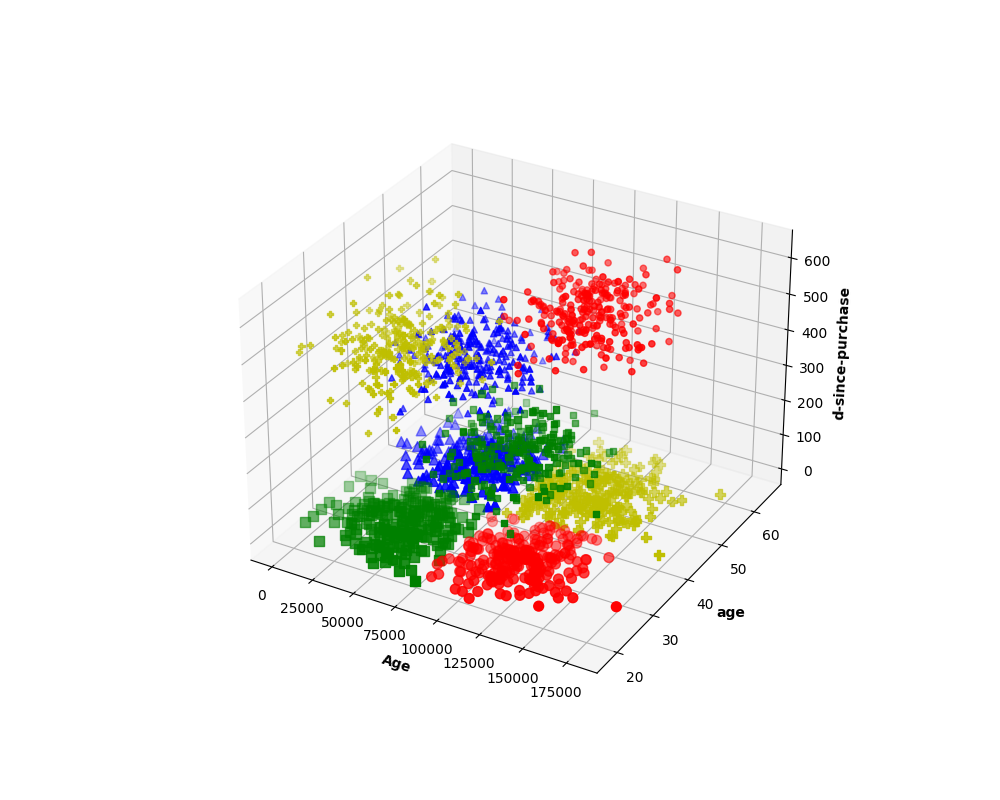

In [54]:
# membuat looping untuk visual dari hasil clustering MeanShift
for c in df['cluster_ms'].unique():
  d = df[df['cluster_ms'] == c]
  plt.scatter(x = d['income'], y = d['age'], marker = marker[c], c = color[c], s=50)

plt.xlabel("Income")
plt.xlabel("Age")
plt.show()

### Categorical Clustering dengan K-Prototype

In [55]:
# install package/library kmodes
!pip install kmodes

In [56]:
# import library KPrototype
from kmodes.kprototypes import KPrototypes

In [58]:
# import data clustering
!wget --no-check-certificate https://raw.githubusercontent.com/lukpras/Data-Science-for-Marketing-Analytics/master/Lesson04/age_education.csv

--2024-09-05 06:38:06--  https://raw.githubusercontent.com/lukpras/Data-Science-for-Marketing-Analytics/master/Lesson04/age_education.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28765 (28K) [text/plain]
Saving to: ‘age_education.csv’

age_education.csv   100%[===================>]  28.09K  --.-KB/s    in 0.002s  

2024-09-05 06:38:06 (14.3 MB/s) - ‘age_education.csv’ saved [28765/28765]



In [59]:
# masukan data kedalam dataframe pandas
df3 = pd.read_csv('/content/age_education.csv')

In [60]:
# cek dataframe
df3.head()

,age,education
0,27.007219,college
1,47.615409,highschool
2,51.382815,highschool
3,54.906622,highschool
4,27.719939,less_than_highschool


In [61]:
# membuat standarisasi untuk kolom umur
df3['z_age'] = (df3['age'] - df3['age'].mean()) / df3['age'].std()
df3.head()

,age,education,z_age
0,27.007219,college,-1.446258
1,47.615409,highschool,0.438698
2,51.382815,highschool,0.783290
3,54.906622,highschool,1.105599
4,27.719939,less_than_highschool,-1.381068


In [62]:
# definisikan value untuk nilai yang akan di clustering
X = df3[['z_age', 'education']].values

# buat model untuk 3 cluster
kp = KPrototypes(n_clusters=3)

# input hasil clustering kedalam dataframe
df3['cluster'] = kp.fit_predict(X, categorical=[1])

In [63]:
# cek hasil clustering
df3.tail()

,age,education,z_age,cluster
995,57.550481,less_than_highschool,1.347424,2
996,23.726849,college,-1.746302,1
997,52.828647,highschool,0.915534,0
998,54.411223,highschool,1.060287,0
999,48.481719,less_than_highschool,0.517937,2


### Standarisasi dengan One-Hot Encoding

In [64]:
# cek nilai unik dari kolom education
df3.education.unique()

array(['college', 'highschool', 'less_than_highschool'], dtype=object)

In [65]:
# lakukan one-hot encoding untuk kolom categorical (education)
df3 = pd.concat([df3, pd.get_dummies(df3['education'])], axis=1)

In [66]:
# cek kembali dataframe
df3.head()

,age,education,z_age,cluster,college,highschool,less_than_highschool
0,27.007219,college,-1.446258,1,True,False,False
1,47.615409,highschool,0.438698,0,False,True,False
2,51.382815,highschool,0.783290,0,False,True,False
3,54.906622,highschool,1.105599,0,False,True,False
4,27.719939,less_than_highschool,-1.381068,1,False,False,True


In [67]:
# cek cluster pertama
cluster_0 = df3[df3['cluster'] == 0]
cluster_0.head()

,age,education,z_age,cluster,college,highschool,less_than_highschool
1,47.615409,highschool,0.438698,0,False,True,False
2,51.382815,highschool,0.783290,0,False,True,False
3,54.906622,highschool,1.105599,0,False,True,False
6,46.790834,highschool,0.363278,0,False,True,False
8,50.208061,college,0.675839,0,True,False,False


### Evaluasi Model

In [68]:
# cek nilai rata2 dari kolom kategori yang telah dilakukan one-hot encoding
means = cluster_0[['college', 'highschool', 'less_than_highschool']].mean()
means

,0
college,0.084034
highschool,0.915966
less_than_highschool,0.000000


<BarContainer object of 3 artists>

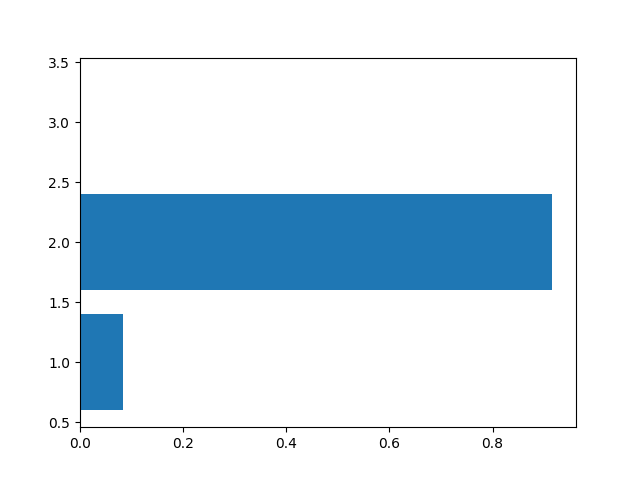

In [69]:
# buat visual dari rata2 kolom hasil clustering
fig, ax = plt.subplots()

plt.barh([1, 2, 3], means)

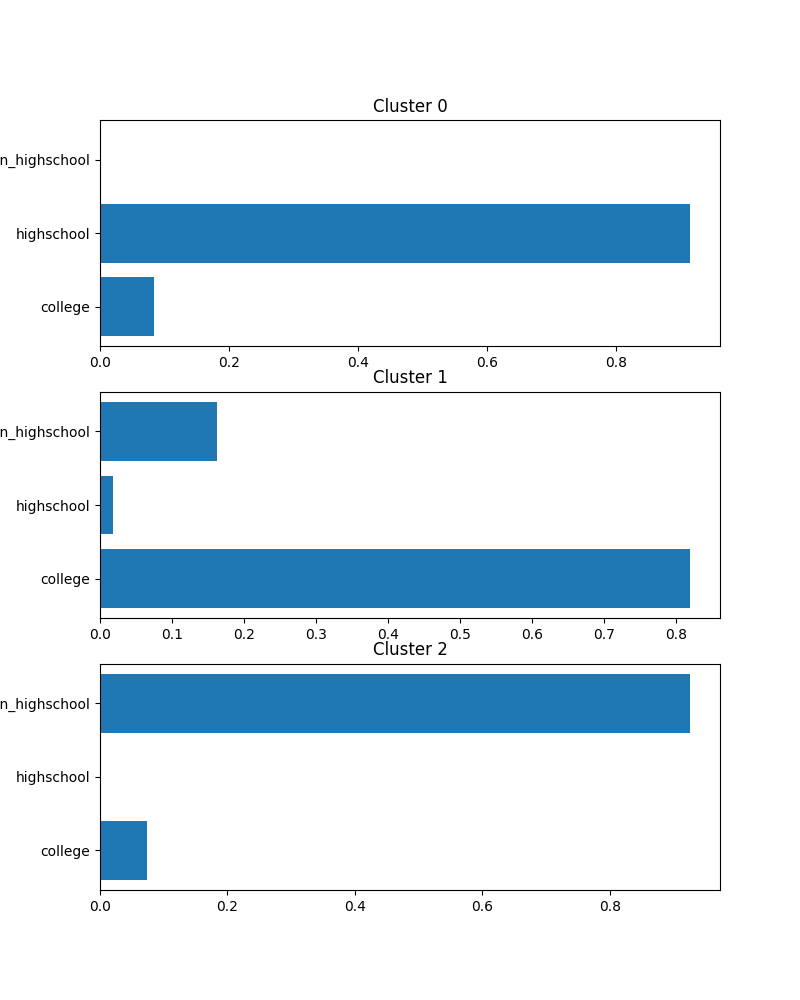

In [70]:
# mwmbuR visual sebaran kategori untuk setiap cluster

# definisikan besar visual
plt.figure(figsize=(8,10))

# membuat looping untuk 3 cluster
for i in range(3):
  # definisikan nilai looping setiap kolom visual
  cluster_df = df3[df3['cluster'] == i]

  # hitung nilai rata2 dari setiap kategori
  means = cluster_df[['college', 'highschool', 'less_than_highschool']].mean()

  # membuat kotak visaul untuk ditempati oleh setiap cluster
  ax = plt.subplot(3, 1, i+1)

  # membuat visaul barchart horizontal setiap cluster
  plt.barh([1, 2, 3], means)

  # definisikan jumlah titik axis y
  ax.set_yticks([1,2,3])

  # definisikan label untuk setiap axis y
  ax.set_yticklabels(['college', 'highschool', 'less_than_highschool'])

  # membuat title untuk setiap kotak visual
  ax.set_title("Cluster " + str(i))

### Pemilihan Model dengan Silhouette

In [71]:
# import dataset
!wget --no-check-certificate https://raw.githubusercontent.com/lukpras/Data-Science-for-Marketing-Analytics/master/Lesson04/four_cols.csv

--2024-09-05 06:41:42--  https://raw.githubusercontent.com/lukpras/Data-Science-for-Marketing-Analytics/master/Lesson04/four_cols.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18326 (18K) [text/plain]
Saving to: ‘four_cols.csv’

four_cols.csv       100%[===================>]  17.90K  --.-KB/s    in 0s      

2024-09-05 06:41:42 (82.0 MB/s) - ‘four_cols.csv’ saved [18326/18326]



In [72]:
# definisikan dataset kedalam dataframe pandas
df4 = pd.read_csv('/content/four_cols.csv')

In [73]:
# cek dataframe
df4.head()

,income,age,days_since_purchase,annual_spend
0,37453,48,504,4441
1,50775,50,566,4239
2,71047,41,326,5834
3,52239,52,259,5456
4,112343,27,279,1749


### Preprocessing dengan Standarisasi

In [74]:
# membuat standarisasi untuk setiap kolom numerik
zkolom4 = []
kolom4 = df4.columns
for kolom in kolom4:
  df4['z_' + kolom] = (df4[kolom] - df4[kolom].mean()) / df4[kolom].std()
  zkolom4.append('z_' + kolom)

In [75]:
# cek dataframe kembali
df4.head()

,income,age,days_since_purchase,annual_spend,z_income,z_age,z_days_since_purchase,z_annual_spend
0,37453,48,504,4441,-0.889981,0.604558,0.752880,0.062245
1,50775,50,566,4239,-0.552817,0.788959,1.305708,-0.058910
2,71047,41,326,5834,-0.039758,-0.040845,-0.834271,0.897732
3,52239,52,259,5456,-0.515765,0.973360,-1.431681,0.671017
4,112343,27,279,1749,1.005394,-1.331651,-1.253350,-1.552352


### Membuat Model

In [76]:
# import library untuk melakukan splitting data
from sklearn.model_selection import train_test_split

In [77]:
# pisahkan dataset kedalam data training dan data testing
X_train, X_test = train_test_split(df4[zkolom4], train_size = 0.8, random_state=10)
X_train.head()

,z_income,z_age,z_days_since_purchase,z_annual_spend
188,1.447159,0.512358,0.137636,1.309179
194,0.661625,-1.239450,-0.932353,-1.314241
225,0.895832,-0.778448,-1.342515,-0.294622
580,0.744840,-1.331651,-1.797261,-0.908193
428,0.288928,1.065560,0.422967,1.167032


In [78]:
# cek dataset testing
X_test.head()

,z_income,z_age,z_days_since_purchase,z_annual_spend
841,-0.158532,-1.055049,-0.370609,-1.341231
956,1.026426,0.696759,0.226802,1.385350
544,-0.586402,0.512358,-1.253350,0.521073
173,0.540775,-1.608252,-1.092851,-0.911191
759,-0.636311,0.235756,-1.378182,0.692609


In [79]:
# cek jumlah pemisahan data
print("train data", len(X_train))
print("test data", len(X_test))

train data 800
test data 200


In [80]:
# import library untuk mengitung nilai silhouette
from sklearn.metrics import silhouette_score

In [81]:
# looping model untuk beberapa cluster dan hitung nilai silhouette
sil = []
krange = list(range(2, 11))
for n in krange:
  model = KMeans(n_clusters=n, random_state= 10)
  klaster = model.fit_predict(df4[zkolom4])
  sil_avg = silhouette_score(df4[zkolom4], klaster)
  sil.append(sil_avg)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

### Evaluasi Model

In [82]:
# cek nilai silhouette
sil

[0.3976663550234901,
 0.4367844164815246,
 0.4444649277848981,
 0.4731327191810766,
 0.39616728508350424,
 0.33986556647751875,
 0.2569739465428213,
 0.2409488254104808,
 0.1762940803057403]

In [83]:
# membuat visual nilai silhouette
ax = plt.axes(projection= None)
plt.plot(krange, sil)

In [84]:
# gunakan model MeanShift untuk clustering data training
bw = estimate_bandwidth(X_train, quantile=0.1)
ms = MeanShift(bandwidth=bw)
ms.fit(X_train)

MeanShift(bandwidth=1.1311759226218492)

In [85]:
# cek hasil clustering
ms_labels = ms.predict(X_test)

In [86]:
# cek nilai silhouette dari hasil clustering
ms_sil = silhouette_score(X_test, ms_labels)
ms_sil

0.3729064875381907

In [87]:
# lakukan clustering clustering dengan model KMeans dan hitung nilai sihouette
model = KMeans(n_clusters=6, random_state= 10)
model.fit(X_train)
km_labels = model.predict(X_test)
km_sil = silhouette_score(X_test, km_labels)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [88]:
km_sil

0.37132642493133844